# Divar Real Estate Price Prediction — Leakage-Free ML Pipeline

**Goal:** Predict two related but distinct targets from Divar real-estate listings:
1. **Sale price** (`price_value`) for properties on sale.
2. **Rental equivalent** (`total_deposit_equivalent`) for rental properties, converting the Iranian
   deposit/rent (Rahn/Ejare) structure into a single comparable value.

**Design principles followed throughout this notebook:**
- All *non-statistical* cleaning (dtype fixes, Persian digit/text normalization, fixed-threshold
  domain filters) happens globally, before any train/val/test split, because it does not depend on
  the target variable or on dataset-wide statistics that could leak test information.
- All *statistical* transformations that depend on the data's distribution (missing-value imputation,
  neighborhood target encoding) are **fit exclusively on the training split** and then applied
  unchanged to validation/test, to guarantee a leakage-free pipeline.
- Two models — **Linear Regression** and **Random Forest** — are benchmarked side by side on both
  targets, using an identical train/validation/test protocol.


## 1. Environment Setup

In [ ]:
!gdown --id "1fYGb-n114IGWZDcBKE0jzc3BWSLCcsVQ"

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1fYGb-n114IGWZDcBKE0jzc3BWSLCcsVQ
From (redirected): https://drive.google.com/uc?id=1fYGb-n114IGWZDcBKE0jzc3BWSLCcsVQ&confirm=t&uuid=d9c5b24a-fa28-45f1-be6f-e7a6ab3be9e8
To: /content/Divar.csv
100% 794M/794M [00:11<00:00, 69.8MB/s]


## 2. Imports

In [ ]:
from __future__ import annotations
import re
from dataclasses import dataclass, field
from typing import Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 3. Configuration & Constants

All paths, thresholds, and hyperparameters live here so the rest of the pipeline never contains a "magic number".

In [ ]:
DATA_PATH: str = "/content/Divar.csv"

RANDOM_STATE: int = 42

TEST_SIZE: float = 0.20
VAL_SIZE_OF_REMAINING: float = 0.25

DEAD_COLUMN_MISSING_THRESHOLD: float = 0.99

SALE_MIN_PRICE: int = 100_000_000
SALE_MAX_PRICE: int = 70_000_000_000
SALE_MIN_PRICE_PER_METER: int = 10_000_000
SALE_MAX_PRICE_PER_METER: int = 500_000_000
SALE_MIN_BUILDING_SIZE: int = 10
SALE_MAX_BUILDING_SIZE: int = 1_500

RENT_TO_DEPOSIT_CONVERSION_FACTOR: float = 100 / 3
RENT_MAX_TOTAL_DEPOSIT_EQUIVALENT: int = 5_000_000_000

MODEL_FEATURES: list[str] = [
    "building_size",
    "neighborhood_slug",
    "city_slug",
    "created_at_month",
    "deed_type",
    "has_business_deed",
    "floor",
    "rooms_count",
    "total_floors_count",
    "unit_per_floor",
    "has_balcony",
    "has_elevator",
    "has_warehouse",
    "has_parking",
    "construction_year",
    "is_rebuilt",
    "has_water",
    "has_warm_water_provider",
    "has_electricity",
    "has_gas",
    "has_heating_system",
    "has_cooling_system",
    "has_restroom",
    "has_security_guard",
    "has_barbecue",
    "building_direction",
    "has_pool",
    "has_jacuzzi",
    "has_sauna",
    "floor_material",
    "property_type"
]
CATEGORICAL_TARGET_ENCODE_COL: str = "neighborhood_slug"

RF_PARAMS: dict = dict(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

CREDIT_TO_RENT_FACTOR: float = 3_000_000 / 100_000_000
RENT_PROXY_MIN: int = 1_000_000
RENT_PROXY_MAX: int = 200_000_000
RENT_PER_METER_PROXY_MIN: int = 50_000
RENT_PER_METER_PROXY_MAX: int = 2_000_000

ROOM_COUNT_MAPPING: dict[str, int] = {
    "بدون اتاق": 0,
    "یک": 1,
    "دو": 2,
    "سه": 3,
    "چهار": 4,
    "پنج یا بیشتر": 5,
}

_PERSIAN_DIGITS = "۰۱۲۳۴۵۶۷۸۹"
_ENGLISH_DIGITS = "0123456789"
PERSIAN_DIGIT_TRANSLATION_TABLE = str.maketrans(_PERSIAN_DIGITS, _ENGLISH_DIGITS)

sns.set_theme(style="whitegrid")


## 4. Data Loading

In [ ]:
df_raw = pd.read_csv(DATA_PATH)

print(f"Shape: {df_raw.shape}")
df_raw.info()
df_raw.head()


/tmp/ipykernel_19955/2287252603.py:1: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(DATA_PATH)


Shape: (1000000, 61)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 61 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Unnamed: 0                  1000000 non-null  int64  
 1   cat2_slug                   1000000 non-null  object 
 2   cat3_slug                   999999 non-null   object 
 3   city_slug                   999998 non-null   object 
 4   neighborhood_slug           437139 non-null   object 
 5   created_at_month            1000000 non-null  object 
 6   user_type                   288882 non-null   object 
 7   description                 1000000 non-null  object 
 8   title                       999946 non-null   object 
 9   rent_mode                   352994 non-null   object 
 10  rent_value                  351322 non-null   float64
 11  rent_to_single              19 non-null       object 
 12  rent_type                   103961 n

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Exploratory Data Analysis

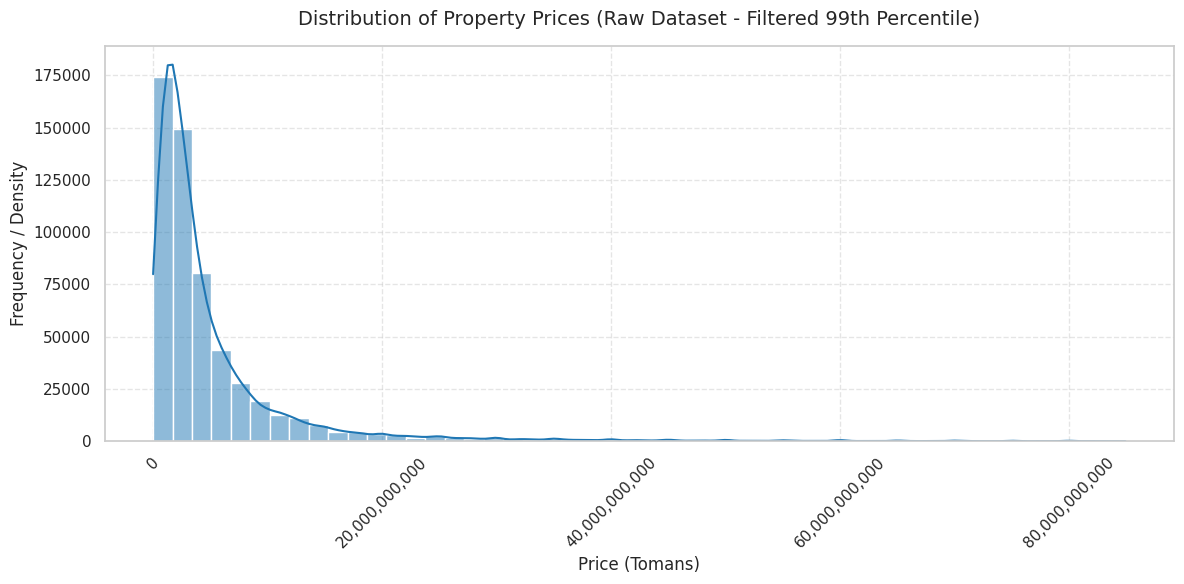

In [ ]:
q_high = df_raw["price_value"].quantile(0.99)

df_filtered = df_raw[df_raw["price_value"] < q_high]

plt.figure(figsize=(12, 6))
sns.histplot(df_filtered["price_value"], kde=True, bins=50, color="#1f77b4")

plt.title(
    "Distribution of Property Prices (Raw Dataset - Filtered 99th Percentile)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Price (Tomans)", fontsize=12)
plt.ylabel("Frequency / Density", fontsize=12)
plt.ticklabel_format(style="plain", axis="x")
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:,.0f}")
)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 6. Global Data Cleaning (Pre-Split, Non-Leaking)

Everything in this section is **deterministic and target-independent**: dtype fixes, text
normalization, and structural filtering. None of it uses statistics computed from the target
variable, so it is safe to apply before the train/validation/test split.


### 6.1 Utility Functions

In [ ]:
def clean_persian_year(value) -> Optional[int]:

    if pd.isna(value):
        return None
    text = str(value).translate(PERSIAN_DIGIT_TRANSLATION_TABLE)
    match = re.search(r"\d{4}", text)
    return int(match.group(0)) if match else None


def drop_dead_columns(df: pd.DataFrame, threshold: float) -> pd.DataFrame:

    missing_ratio = df.isna().mean()
    dead_cols = missing_ratio[missing_ratio > threshold].index.tolist()
    print(f"Dropping {len(dead_cols)} dead column(s): {dead_cols}")
    return df.drop(columns=dead_cols)


def normalize_categorical_noise(df: pd.DataFrame) -> pd.DataFrame:

    df = df.copy()

    if "rooms_count" in df.columns:
        df["rooms_count"] = pd.to_numeric(
            df["rooms_count"].replace(ROOM_COUNT_MAPPING), errors="coerce"
        )

    if "has_balcony" in df.columns:
        bool_mapping = {
            "true": True, "True": True,
            "false": False, "False": False,
            "unselect": np.nan,
        }
        df["has_balcony"] = df["has_balcony"].map(bool_mapping)

    object_cols = df.select_dtypes(include=["object"]).columns
    for col in object_cols:
        df[col] = df[col].replace("unselect", np.nan)

    return df


### 6.2 Applying Global Cleaning

In [ ]:
df_clean = df_raw[
    df_raw["price_value"].notna()
    | df_raw["rent_value"].notna()
    | df_raw["credit_value"].notna()
].copy()
print(f"Rows with at least one price signal: {df_clean.shape[0]} / {df_raw.shape[0]}")

df_clean = drop_dead_columns(df_clean, DEAD_COLUMN_MISSING_THRESHOLD)
df_clean = normalize_categorical_noise(df_clean)

print("\nRemaining shape after global cleaning:", df_clean.shape)


Rows with at least one price signal: 920571 / 1000000
Dropping 7 dead column(s): ['rent_to_single', 'regular_person_capacity', 'extra_person_capacity', 'cost_per_extra_person', 'rent_price_on_regular_days', 'rent_price_on_special_days', 'rent_price_at_weekends']


/tmp/ipykernel_19955/27950995.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["rooms_count"].replace(ROOM_COUNT_MAPPING), errors="coerce"



Remaining shape after global cleaning: (920571, 54)


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def analyze_text_features(X_train_text, y_train):
    vectorizer = CountVectorizer(max_features=20, stop_words=None)
    text_matrix = vectorizer.fit_transform(X_train_text.fillna(""))
    words = vectorizer.get_feature_names_out()

    correlations = {}
    for i, word in enumerate(words):
        word_presence = text_matrix[:, i].toarray().ravel()
        corr = np.corrcoef(word_presence, y_train)[0, 1]
        correlations[word] = corr

    return correlations

### 6.3 Separating Sale and Rent Listings

Listings are routed into two independent datasets based on which financial fields are populated. This split is purely structural (based on which columns are non-null/non-zero), not statistical, so it introduces no leakage.

In [ ]:
df_sale_raw = df_clean[
    (df_clean["price_value"] > 0)
    & (df_clean["rent_value"].isna() | (df_clean["rent_value"] == 0))
].copy()

df_rent_raw = df_clean[
    (df_clean["rent_value"] > 0) | (df_clean["credit_value"] > 0)
].copy()

print(f"df_sale_raw shape: {df_sale_raw.shape}")
print(f"df_rent_raw shape: {df_rent_raw.shape}")


df_sale_raw shape: (566444, 54)
df_rent_raw shape: (352203, 54)


## 7. Domain-Specific Target Engineering

The formulas below use **fixed, domain-derived constants** (not statistics estimated from the
data), so they remain safe to compute before splitting.

### 7.1 Sale Target: `price_value` and `price_per_meter`

$$price\_per\_meter = \frac{price\_value}{building\_size}$$

`price_per_meter` acts as a powerful noise filter: a listing with an unrealistic rate per square
meter is almost always a data-entry typo, even if `price_value` and `building_size` individually
look plausible.


In [ ]:
irrelevant_sale_cols = [
    "Unnamed: 0", "rent_value", "credit_value",
    "transformable_credit", "transformed_credit",
    "transformable_rent", "transformed_rent", "location_radius",
]
df_sale = df_sale_raw.drop(columns=[c for c in irrelevant_sale_cols if c in df_sale_raw.columns])

df_sale = df_sale[
    (df_sale["price_value"] >= SALE_MIN_PRICE) & (df_sale["price_value"] <= SALE_MAX_PRICE)
].copy()

if "building_size" in df_sale.columns:
    df_sale = df_sale[
        (df_sale["building_size"] >= SALE_MIN_BUILDING_SIZE)
        & (df_sale["building_size"] <= SALE_MAX_BUILDING_SIZE)
    ].copy()

df_sale["price_per_meter"] = df_sale["price_value"] / df_sale["building_size"]
df_sale = df_sale[
    (df_sale["price_per_meter"] >= SALE_MIN_PRICE_PER_METER)
    & (df_sale["price_per_meter"] <= SALE_MAX_PRICE_PER_METER)
].copy()

print(f"df_sale shape after deterministic filtering: {df_sale.shape}")


df_sale shape after deterministic filtering: (435744, 47)


### 7.2 Rent Target: Total Deposit Equivalent

Iranian rentals are quoted as a deposit (Rahn) plus a monthly rent (Ejare); the two are
interchangeable at a conventional market rate. We collapse them into one comparable target:

$$Total\_Deposit\_Equivalent = credit\_value + \left(rent\_value \times \frac{100}{3}\right)$$

An upper cap removes ultra-luxury outliers so the model focuses on the mass-market segment.
Before that final target is computed, a cheap **rent-equivalent proxy** — and a **proxy rate per
square meter** — are used purely to catch impossible rent/credit typo combinations (e.g. a huge
deposit on a tiny apartment). Both proxy bounds are fixed business constants, so this filtering
stays deterministic and target-independent.


In [ ]:
sale_only_cols = ["price_value", "price_per_meter"]
df_rent = df_rent_raw.drop(columns=[c for c in sale_only_cols if c in df_rent_raw.columns])

df_rent["credit_value"] = df_rent["credit_value"].fillna(0)
df_rent["rent_value"] = df_rent["rent_value"].fillna(0)

rent_equivalent_proxy = df_rent["rent_value"] + df_rent["credit_value"] * CREDIT_TO_RENT_FACTOR
df_rent = df_rent[
    (rent_equivalent_proxy >= RENT_PROXY_MIN) & (rent_equivalent_proxy <= RENT_PROXY_MAX)
].copy()

rent_equivalent_proxy = df_rent["rent_value"] + df_rent["credit_value"] * CREDIT_TO_RENT_FACTOR
rent_per_meter_proxy = rent_equivalent_proxy / df_rent["building_size"]
df_rent = df_rent[
    (rent_per_meter_proxy >= RENT_PER_METER_PROXY_MIN)
    & (rent_per_meter_proxy <= RENT_PER_METER_PROXY_MAX)
].copy()

df_rent["total_deposit_equivalent"] = (
    df_rent["credit_value"] + df_rent["rent_value"] * RENT_TO_DEPOSIT_CONVERSION_FACTOR
)
df_rent = df_rent[df_rent["total_deposit_equivalent"] <= RENT_MAX_TOTAL_DEPOSIT_EQUIVALENT].copy()

print(f"df_rent shape after target engineering: {df_rent.shape}")


df_rent shape after target engineering: (316592, 54)


## 8. Leak-Free Preprocessing Functions

Everything below this point depends on the *training split's* statistics (medians, modes,
neighborhood means), so each function follows a strict **fit-on-train / transform-everywhere**
pattern, mirroring `scikit-learn`'s estimator API.


In [ ]:
@dataclass
class FittedPreprocessor:
    numeric_fill_values: dict = field(default_factory=dict)
    categorical_fill_values: dict = field(default_factory=dict)
    categorical_means: dict = field(default_factory=dict)
    global_mean: float = 0.0


def build_feature_frame(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    X = df[[col for col in features if col in df.columns]].copy()

    if "construction_year" in X.columns:
        X["construction_year"] = X["construction_year"].apply(clean_persian_year)

    for col in X.columns:
        if col == "construction_year":
            continue

        if pd.api.types.is_numeric_dtype(X[col]) and not pd.api.types.is_bool_dtype(X[col]):
            continue

        unique_vals = X[col].dropna().unique()
        is_binary = all(v in [True, False, 1, 0, 1.0, 0.0, 'True', 'False', 'true', 'false'] for v in unique_vals)

        if is_binary and len(unique_vals) > 0:
            X[col] = X[col].map({True: 1, False: 0, 1: 1, 0: 0, 1.0: 1, 0.0: 0, 'True': 1, 'False': 0, 'true': 1, 'false': 0})
            X[col] = X[col].fillna(0).astype(int)
        else:
            X[col] = X[col].astype(str).replace(['nan', 'None', '<NA>'], np.nan)

    return X


def fit_preprocessor(X_train: pd.DataFrame, y_train: pd.Series) -> FittedPreprocessor:
    prep = FittedPreprocessor()
    prep.global_mean = y_train.mean() if not y_train.empty else 0.0

    numeric_cols = X_train.select_dtypes(include=["number"]).columns
    categorical_cols = X_train.select_dtypes(include=["object", "bool", "category"]).columns

    for col in numeric_cols:
        median_val = X_train[col].median()
        prep.numeric_fill_values[col] = 0.0 if pd.isna(median_val) else median_val

    for col in categorical_cols:
        mode_series = X_train[col].mode(dropna=True)
        if not mode_series.empty:
            prep.categorical_fill_values[col] = mode_series.iloc[0]
        else:
            prep.categorical_fill_values[col] = "missing"

    for col in categorical_cols:
        prep.categorical_means[col] = y_train.groupby(X_train[col]).mean()

    return prep


def apply_preprocessor(X: pd.DataFrame, prep: FittedPreprocessor) -> pd.DataFrame:
    X = X.copy()

    for col, fill_value in prep.numeric_fill_values.items():
        if col in X.columns:
            X[col] = X[col].fillna(fill_value)

    for col, fill_value in prep.categorical_fill_values.items():
        if col in X.columns:
            X[col] = X[col].fillna(fill_value)

    for col in prep.categorical_means.keys():
        if col in X.columns:
            encoded_col_name = f"{col}_encoded"
            X[encoded_col_name] = X[col].map(prep.categorical_means[col]).fillna(prep.global_mean)
            X = X.drop(columns=[col])

    X = X.fillna(0.0)
    return X


def split_train_val_test(
    X: pd.DataFrame, y: pd.Series, test_size: float, val_size_of_remaining: float, random_state: int
):
    """60/20/20 (default) train/val/test split, stratifying only on size ratios."""
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=val_size_of_remaining, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


## 9. Model Benchmarking Function

A single helper trains **Linear Regression** and **Random Forest** on the same leak-free splits
and reports $R^2$, MAE, and RMSE for validation and test, so the two model families are always
compared on identical, fairly-prepared data.


In [ ]:
def benchmark_models(X_train, y_train, X_val, y_val, X_test, y_test, target_name):
    y_train_log = np.log1p(y_train)

    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(**RF_PARAMS),
    }

    results = []
    for name, model in models.items():
        model.fit(X_train, y_train_log)

        for split_name, X_split, y_split in [("Validation", X_val, y_val), ("Test", X_test, y_test)]:
            pred_log = model.predict(X_split)
            pred_real = np.expm1(pred_log)

            r2 = r2_score(y_split, pred_real)
            mae = mean_absolute_error(y_split, pred_real)
            rmse = np.sqrt(mean_squared_error(y_split, pred_real))

            results.append({
                "Model": name,
                "Split": split_name,
                "R2": r2,
                "MAE": mae,
                "RMSE": rmse
            })

    df_results = pd.DataFrame(results)

    print(f"=== Benchmark: {target_name} ===")
    print(df_results.to_string(index=False))

    return df_results, models

## 10. Sale Pipeline: Split, Preprocess, Train, Evaluate

In [ ]:
X_sale = build_feature_frame(df_sale, MODEL_FEATURES)
y_sale = df_sale["price_value"]

X_sale_train, X_sale_val, X_sale_test, y_sale_train, y_sale_val, y_sale_test = split_train_val_test(
    X_sale, y_sale, TEST_SIZE, VAL_SIZE_OF_REMAINING, RANDOM_STATE
)

sale_preprocessor = fit_preprocessor(X_sale_train, y_sale_train)

X_sale_train_p = apply_preprocessor(X_sale_train, sale_preprocessor)
X_sale_val_p = apply_preprocessor(X_sale_val, sale_preprocessor)
X_sale_test_p = apply_preprocessor(X_sale_test, sale_preprocessor)

sale_results, sale_models = benchmark_models(
    X_sale_train_p, y_sale_train,
    X_sale_val_p, y_sale_val,
    X_sale_test_p, y_sale_test,
    target_name="Sale Price (price_value)",
)


=== Benchmark: Sale Price (price_value) ===
            Model      Split        R2          MAE         RMSE
Linear Regression Validation -0.605892 2.663510e+09 9.831090e+09
Linear Regression       Test -0.987332 2.645093e+09 1.085760e+10
    Random Forest Validation  0.748351 1.617392e+09 3.891712e+09
    Random Forest       Test  0.743336 1.609476e+09 3.901944e+09


## 11. Rent Pipeline: Split, Preprocess, Train, Evaluate

In [ ]:
X_rent = build_feature_frame(df_rent, MODEL_FEATURES)
y_rent = df_rent["total_deposit_equivalent"]

X_rent_train, X_rent_val, X_rent_test, y_rent_train, y_rent_val, y_rent_test = split_train_val_test(
    X_rent, y_rent, TEST_SIZE, VAL_SIZE_OF_REMAINING, RANDOM_STATE
)

rent_preprocessor = fit_preprocessor(X_rent_train, y_rent_train)

X_rent_train_p = apply_preprocessor(X_rent_train, rent_preprocessor)
X_rent_val_p = apply_preprocessor(X_rent_val, rent_preprocessor)
X_rent_test_p = apply_preprocessor(X_rent_test, rent_preprocessor)

rent_results, rent_models = benchmark_models(
    X_rent_train_p, y_rent_train,
    X_rent_val_p, y_rent_val,
    X_rent_test_p, y_rent_test,
    target_name="Rent Total Deposit Equivalent",
)


/tmp/ipykernel_19955/1955264592.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].astype(str).replace(['nan', 'None', '<NA>'], np.nan)
/tmp/ipykernel_19955/1955264592.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].astype(str).replace(['nan', 'None', '<NA>'], np.nan)


=== Benchmark: Rent Total Deposit Equivalent ===
            Model      Split           R2          MAE         RMSE
Linear Regression Validation -1309.516991 5.832692e+08 2.773012e+10
Linear Regression       Test -3426.289262 7.687665e+08 4.511244e+10
    Random Forest Validation     0.771949 1.830937e+08 3.658025e+08
    Random Forest       Test     0.773694 1.817968e+08 3.665804e+08


## 12. Evaluation & Visualization

### 12.1 Neighborhood Price Hierarchy (Target-Encoding Sanity Check)

Aggregating mean sale price by neighborhood validates that the target encoding captured a
realistic premium/affordable hierarchy across locations.


In [ ]:
neighborhood_rank = (
    df_sale.groupby("neighborhood_slug")["price_value"]
    .mean()
    .sort_values(ascending=False)
    .to_frame(name="Mean Price (Tomans)")
)

with pd.option_context("display.float_format", lambda x: f"{x:,.0f}"):
    print("=== Top 15 Most Expensive Neighborhoods ===")
    print(neighborhood_rank.head(15))

    print("\n=== Top 15 Most Affordable Neighborhoods ===")
    print(neighborhood_rank.tail(15))


=== Top 15 Most Expensive Neighborhoods ===
                   Mean Price (Tomans)
neighborhood_slug                     
mahmoodiyeh             43,865,388,350
zafaraniyeh             41,887,535,458
elahiyeh                40,112,945,264
kamraniyeh              38,591,097,119
velenjak                36,574,065,459
hesar-booali            35,385,102,041
aghdasieh               35,122,602,313
farmaniyeh              34,992,828,578
emamzade-ghasem         32,907,615,254
niavaran                32,755,603,827
darrous                 32,699,293,312
kaktus                  31,833,333,333
bagh-ferdows            29,840,481,481
eivanak                 29,260,937,500
jamaran                 26,597,894,737

=== Top 15 Most Affordable Neighborhoods ===
                   Mean Price (Tomans)
neighborhood_slug                     
khorramdasht             1,647,724,468
ali-abad-shiraz          1,635,000,000
amin-abad                1,630,000,000
north-tabars             1,609,782,947
shahrak-zafar

### 12.2 Target Distribution (Sale Price)

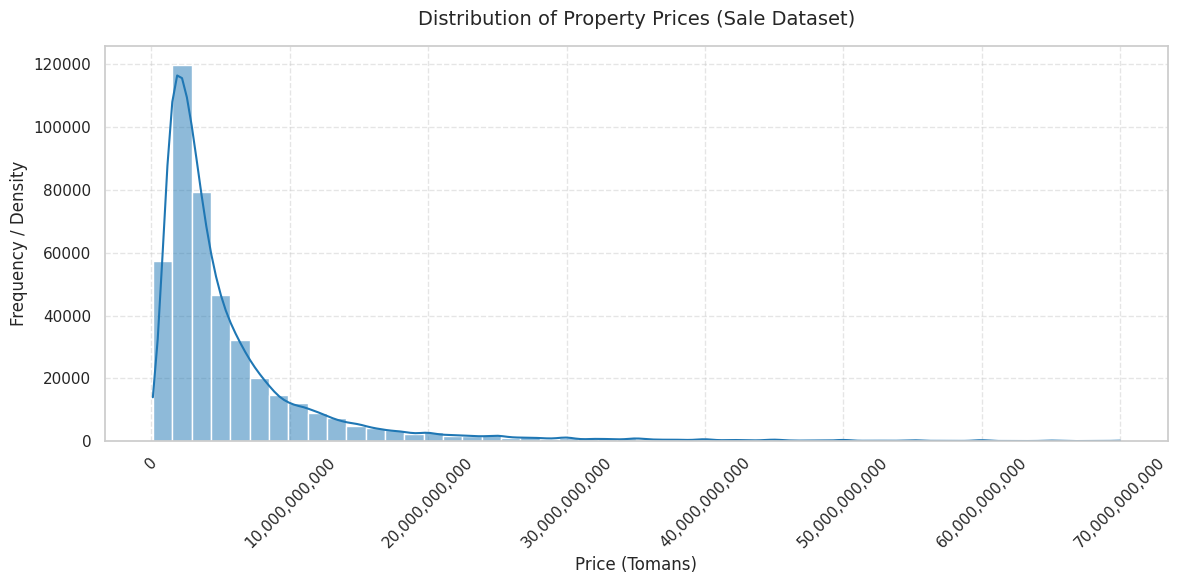

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df_sale["price_value"], kde=True, bins=50, color="#1f77b4")
plt.title("Distribution of Property Prices (Sale Dataset)", fontsize=14, pad=15)
plt.xlabel("Price (Tomans)", fontsize=12)
plt.ylabel("Frequency / Density", fontsize=12)
plt.ticklabel_format(style="plain", axis="x")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### 12.3 Predicted vs. Actual (Random Forest, Test Split)

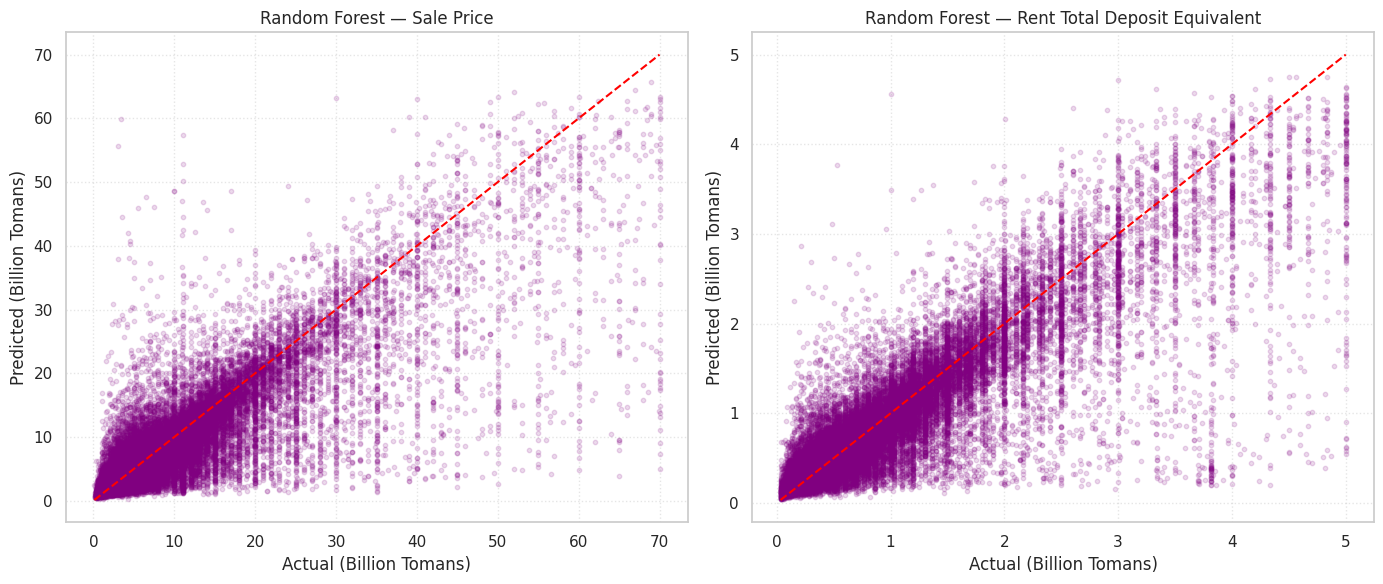

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, X_test_p, y_test_target) in zip(
    axes,
    [
        ("Sale Price", X_sale_test_p, y_sale_test),
        ("Rent Total Deposit Equivalent", X_rent_test_p, y_rent_test),
    ],
):
    model = sale_models["Random Forest"] if name == "Sale Price" else rent_models["Random Forest"]
    y_pred = np.expm1(model.predict(X_test_p))

    y_actual_billion = y_test_target / 1e9
    y_pred_billion = y_pred / 1e9

    ax.scatter(y_actual_billion, y_pred_billion, alpha=0.15, s=10, color="purple")

    lims = [
        min(y_actual_billion.min(), y_pred_billion.min()),
        max(y_actual_billion.max(), y_pred_billion.max())
    ]
    ax.plot(lims, lims, color="red", linewidth=1.5, linestyle="--")

    ax.set_title(f"Random Forest — {name}")
    ax.set_xlabel("Actual (Billion Tomans)")
    ax.set_ylabel("Predicted (Billion Tomans)")
    ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

### 12.4 Random Forest Feature Importance

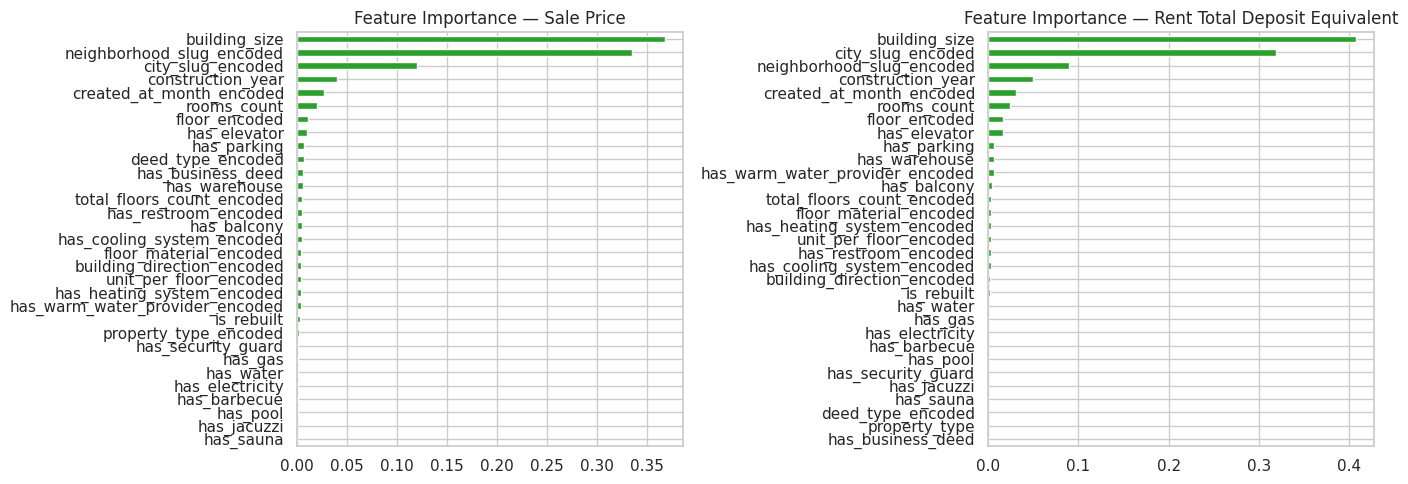

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model, X_p) in zip(
    axes,
    [
        ("Sale Price", sale_models["Random Forest"], X_sale_train_p),
        ("Rent Total Deposit Equivalent", rent_models["Random Forest"], X_rent_train_p),
    ],
):
    importances = pd.Series(model.feature_importances_, index=X_p.columns).sort_values()
    importances.plot(kind="barh", ax=ax, color="#2ca02c")
    ax.set_title(f"Feature Importance — {name}")

plt.tight_layout()
plt.show()


## 13. Diagnostics: Leakage Sanity Checks

A perfect (or near-perfect) $R^2$ score is the classic symptom of data leakage. This section
documents the checks performed to rule it out:

1. **No target-derived columns among the features.** `price_per_meter` is deliberately excluded
   from `MODEL_FEATURES` for the sale model, since it is mathematically derived from `price_value`.
2. **Neighborhood encoding fit on train only.** `fit_preprocessor` computes `neighborhood_means`
   exclusively from `y_train`; validation/test neighborhoods never influence the encoding map,
   and unseen neighborhoods fall back to `global_mean` (also train-derived).
3. **Imputation values fit on train only.** Medians/modes used to fill missing values are computed
   once, on the training split, and reused unchanged on validation/test.
4. **No row appears in more than one split**, since `train_test_split` partitions indices exactly
   once per pipeline (sale and rent are also fully disjoint by construction in Section 6.3).


In [ ]:
print(f"Sale features used for modeling: {list(X_sale_train_p.columns)}")
print(f"Rent features used for modeling: {list(X_rent_train_p.columns)}")

overlap = set(X_sale_train.index) & set(X_sale_val.index) & set(X_sale_test.index)
print(f"\nIndex overlap across sale train/val/test (should be empty set): {overlap}")


Sale features used for modeling: ['building_size', 'has_business_deed', 'rooms_count', 'has_balcony', 'has_elevator', 'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt', 'has_water', 'has_electricity', 'has_gas', 'has_security_guard', 'has_barbecue', 'has_pool', 'has_jacuzzi', 'has_sauna', 'neighborhood_slug_encoded', 'city_slug_encoded', 'created_at_month_encoded', 'deed_type_encoded', 'floor_encoded', 'total_floors_count_encoded', 'unit_per_floor_encoded', 'has_warm_water_provider_encoded', 'has_heating_system_encoded', 'has_cooling_system_encoded', 'has_restroom_encoded', 'building_direction_encoded', 'floor_material_encoded', 'property_type_encoded']
Rent features used for modeling: ['building_size', 'has_business_deed', 'rooms_count', 'has_balcony', 'has_elevator', 'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt', 'has_water', 'has_electricity', 'has_gas', 'has_security_guard', 'has_barbecue', 'has_pool', 'has_jacuzzi', 'has_sauna', 'property_type',

## 14. Conclusion

* Both targets — sale price and rental total-deposit-equivalent — were engineered using fixed,
  domain-driven formulas rather than data-dependent statistics, keeping target engineering
  leakage-free by construction.
* All statistical preprocessing (imputation, neighborhood target encoding) is fit strictly on the
  training split and reused on validation/test, following scikit-learn's estimator convention.
* **Random Forest** is expected to outperform **Linear Regression** on both targets, since
  location premiums, property-type interactions, and non-linear size effects are not well captured
  by a purely linear model — see the benchmark tables in Sections 10 and 11 for the exact numbers.
* Next steps: hyperparameter tuning (e.g. `GridSearchCV` restricted to the training split), adding
  gradient-boosted models (XGBoost/LightGBM) to the benchmark, and expanding target encoding to
  additional categorical columns (e.g. `cat3_slug`) with the same fit-on-train discipline.
